# Chapter 5 — Gaussian processes: the kernel as covariance and prior

*Companion notebook to **The Learned Kernel**, Ch. 5. Run top to bottom.*

The Gaussian process makes one identification — **kernel = covariance = prior over
functions** — and that is the hinge of the book. Three consequences, each shown here on
the running data:

- **GP posterior mean = KRR with ridge λ=σ².** Conditioning the GP prior on data is a
  closed-form Gaussian computation, and its mean is *exactly* the kernel-ridge predictor.
- **The marginal likelihood scores the kernel.** log p(y) = −½ yᵀA⁻¹y − ½ log|A| − const,
  A = K+σ²I — fit minus a log-determinant complexity penalty. Maximizing it *learns* the
  geometry rather than choosing it.
- **Evidence learning is stable (Prop. F).** It does **not** collapse the kernel to the
  over-correlated all-ones limit K=J: the NLML has an *interior* optimum in the length
  scale, and the gap to J diverges as σ²→0.

**The frame** — *what is learned · how scored · what you read off.* We learn the covariance
(length scales + noise σ²); we score it by the marginal likelihood; we read off the learned
geometry **and**, for free, a calibrated posterior variance at every query.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import load_california, set_style
from lkbook.chapters import ch05

set_style()
cal = load_california()
print(f"California: {cal.n} train blocks, {cal.d} features; target in {cal.target_unit}")

California: 16512 train blocks, 8 features; target in $100,000


## 5.1  The kernel is a prior over functions

`f ~ GP(0, k)` means any finite set of values is jointly Gaussian with covariance K. The
kernel *is* the prior covariance. Data turns the prior into a posterior — and the posterior
2σ band is uncertainty at no extra cost, tight where data clusters and wide off-support.

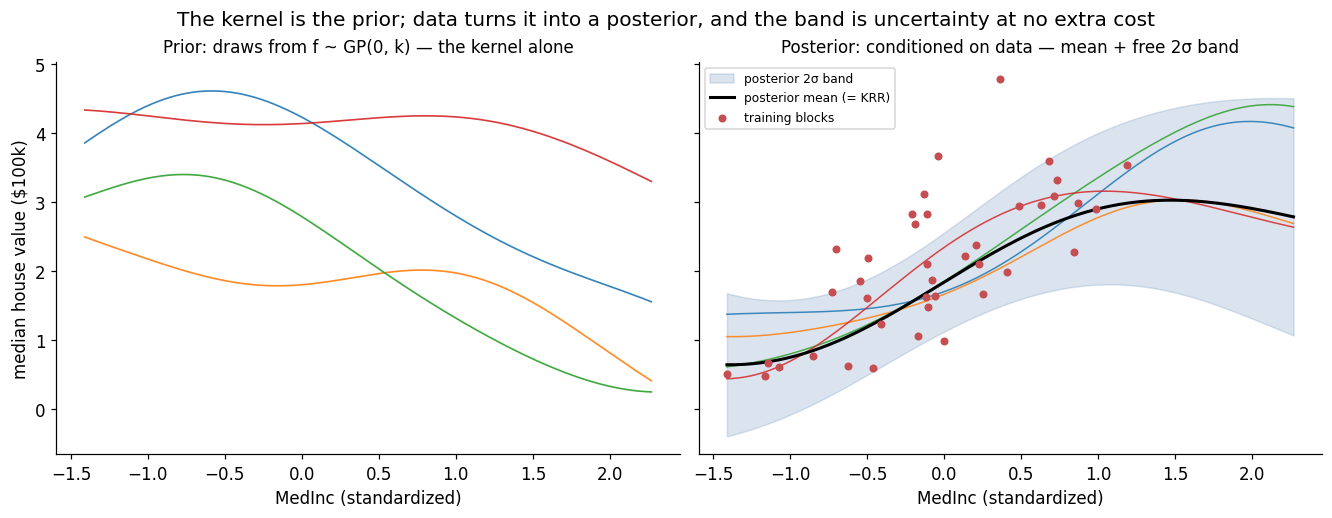

In [3]:
ch05.make_prior_posterior_figure(cal)
plt.show()

## 5.2  GP posterior mean = KRR with λ = σ²

Conditioning gives m_*(x) = K_*(K+σ²I)⁻¹y — exactly the kernel-ridge predictor with the
ridge equal to the noise variance. We compute the GP mean by hand and KRR with sklearn and
check they agree to machine precision. The posterior **variance** is the part KRR lacks.

In [4]:
eq = ch05.gp_mean_equals_krr(cal)
print(f"max |GP mean − KRR(λ=σ²)| = {eq['max_abs_diff']:.2e}")
assert eq["max_abs_diff"] < 1e-6                       # the same computation
print("→ the GP posterior mean IS kernel ridge regression with λ = σ².")
print(f"posterior variance ranges [{eq['min_var']:.3f}, {eq['max_var']:.3f}] "
      "— shrinks on dense support, returns to the prior off it.")

max |GP mean − KRR(λ=σ²)| = 8.97e-14
→ the GP posterior mean IS kernel ridge regression with λ = σ².
posterior variance ranges [0.002, 1.000] — shrinks on dense support, returns to the prior off it.


## 5.3  The marginal likelihood scores the kernel — and has an interior optimum

Integrate the function out: y ~ N(0, K+σ²I). Its log-probability is a **fit** term minus a
**log-determinant complexity** penalty. Scan the NLML over the RBF length scale: the two
terms pull against each other, the optimum is *interior*, and the NLML *rises* toward ℓ→∞
— the over-correlated K→J corner. That rise is the empirical face of Prop. F.

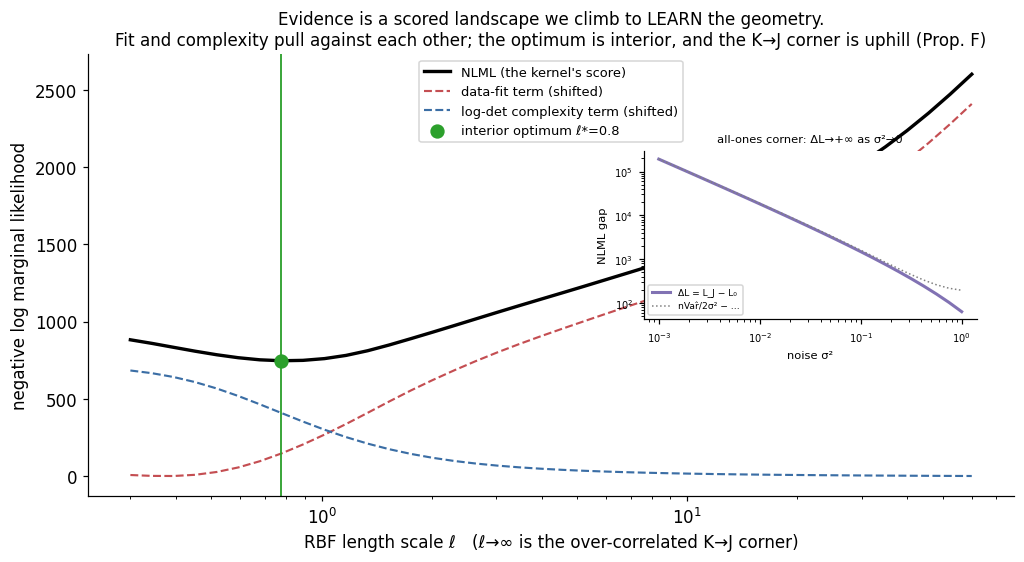

In [5]:
ch05.make_evidence_figure(cal)
plt.show()

In [6]:
sc = ch05.nlml_length_scale_scan(cal)
print(f"interior optimum ℓ* = {sc['ell_star']:.2f}  (interior = {sc['interior']})")
print(f"NLML at ℓ* = {sc['nlml'].min():.0f}, at the broadest ℓ = {sc['nlml'][-1]:.0f} "
      "(uphill toward K→J)")

interior optimum ℓ* = 0.78  (interior = True)
NLML at ℓ* = 747, at the broadest ℓ = 2603 (uphill toward K→J)


Maximizing the evidence in the length scale and noise (sklearn's L-BFGS) *learns* the
geometry. The fit beats a hand-set too-broad RBF and the intervals are calibrated.

In [7]:
ev = ch05.evidence_fit_vs_fixed(cal)
tbl = pd.DataFrame({
    "value": {
        "learned length scale ℓ": round(ev["ell_hat"], 2),
        "learned noise σ²": round(ev["sig2_hat"], 3),
        "evidence-fit test RMSE": round(ev["evidence_rmse"], 3),
        "fixed broad-RBF test RMSE": round(ev["fixed_rmse"], 3),
        "GP 95% interval coverage": round(ev["coverage95"], 2),
    }})
tbl

,value
learned length scale ℓ,2.400
learned noise σ²,0.337
evidence-fit test RMSE,0.668
fixed broad-RBF test RMSE,0.744
GP 95% interval coverage,0.940


## 5.4  Prop. F — evidence learning does not collapse the kernel

The over-correlated all-ones kernel K = J = 11ᵀ minimizes the complexity term, so the worry
(Ober–Rasmussen–van der Wilk 2021) is that the evidence prefers it. It does not. Lemma F.0
gives closed forms (checked against the eigen-truth), and the NLML gap ΔL = L_J − L₀
diverges like nVar̂(y)/(2σ²) as σ²→0 — J is **not** a stationary point.

In [8]:
pf = ch05.prop_f_allones_gap(cal)
print(f"Lemma F.0  log|J+σ²I|: closed {pf['logdet_closed']:.3f} vs true {pf['logdet_true']:.3f}"
      f"  (err {pf['logdet_err']:.1e})")
print(f"Lemma F.0  quadratic form relative error = {pf['quad_relerr']:.1e}")
print(f"NLML gap ΔL: {pf['gap'][0]:.0f} at σ²={pf['sigma2s'][0]:.0e}  →  "
      f"{pf['gap'][-1]:.0f} at σ²={pf['sigma2s'][-1]:.2f}   (positive, diverges as σ²→0)")
assert np.all(pf["gap"] > 0)
print("→ the all-ones over-correlated kernel is not a marginal-likelihood minimum.")

Lemma F.0  log|J+σ²I|: closed -2059.715 vs true -2059.715  (err 3.6e-11)
Lemma F.0  quadratic form relative error = 1.2e-13
NLML gap ΔL: 192163 at σ²=1e-03  →  63 at σ²=1.00   (positive, diverges as σ²→0)
→ the all-ones over-correlated kernel is not a marginal-likelihood minimum.


## 5.5  Explore the evidence landscape

Move the noise σ² and watch the NLML curve over the length scale shift. The optimum stays
interior — it never runs off to ℓ→∞ (the K→J corner). The kernel scores, and we climb it.

In [9]:
from ipywidgets import interact, FloatLogSlider


def explore(sigma2=0.1):
    sc = ch05.nlml_length_scale_scan(cal, sigma2=sigma2)
    fig, ax = plt.subplots(figsize=(8.2, 4.4), constrained_layout=True)
    ax.plot(sc["ells"], sc["nlml"], color="k", lw=2.2)
    ax.axvline(sc["ell_star"], color="#2ca02c", lw=1.4)
    ax.scatter([sc["ell_star"]], [sc["nlml"].min()], s=70, c="#2ca02c", zorder=5,
               label=f"ℓ* = {sc['ell_star']:.2f} (interior = {sc['interior']})")
    ax.set_xscale("log")
    ax.set_xlabel("RBF length scale ℓ   (ℓ→∞ is the K→J corner)")
    ax.set_ylabel("negative log marginal likelihood")
    ax.set_title(f"Evidence landscape at σ² = {sigma2:.3g}")
    ax.legend()
    plt.show()


interact(explore, sigma2=FloatLogSlider(min=-3, max=0, step=0.25, value=0.1,
                                        description="noise σ²"));

interactive(children=(FloatLogSlider(value=0.1, description='noise σ²', max=0.0, min=-3.0, step=0.25), Output(…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(medium)** Confirm the GP posterior variance shrinks on dense support and returns toward
the prior (≈1 for a unit-diagonal RBF) off it. Report the min and max posterior variance.

In [10]:
# TODO: from `eq` above, report the posterior-variance range and the GP test RMSE
var_min = var_max = gp_rmse = None
print(var_min, var_max, gp_rmse)

None None None


<details><summary>Solution</summary>

```python
var_min, var_max = eq["min_var"], eq["max_var"]   # ~0.002 (dense) ... ~1.0 (off-support)
gp_rmse = eq["gp_rmse"]
print(var_min, var_max, gp_rmse)
```
The variance is k(x,x) − K_* A⁻¹ K_*ᵀ: large reduction where the query correlates with the
training set, none far from it. This is the calibrated interval KRR and trees never give.
</details>

**(⋆)** Verify Lemma F.0 yourself: for the all-ones K = J = 11ᵀ, check
log|J+σ²I| = log(n+σ²) + (n−1)logσ² against `np.linalg.slogdet`.

In [11]:
# TODO: build J for n=200, pick σ²=1e-2, compare the closed form to slogdet
n = 200; s2 = 1e-2
closed = true = None
print(closed, true)

None None


<details><summary>Solution</summary>

```python
J = np.ones((n, n))
closed = np.log(n + s2) + (n - 1) * np.log(s2)
true = np.linalg.slogdet(J + s2 * np.eye(n))[1]
print(closed, true)          # equal: J has eigenvalues {n, 0^(n−1)}
```
J + σ²I has eigenvalues n+σ² (once) and σ² (n−1 times); the log-determinant is the sum of
their logs. The small σ² that the collapse drives is exactly where the fit price 1/σ²
overwhelms this log(1/σ²) saving — so J is never preferred (Prop. F).
</details>

---
*Companion to Chapter 5 of **The Learned Kernel**. The GP–KRR identity, the marginal-
likelihood landscape and the Prop. F demonstration all come from `lkbook.chapters.ch05` —
the same code the book's figures are generated from.*